# 24.3 SMOTE(Synthetic Minority Oversampling Technique)

- SMOTE(Synthetic Minority Oversampling Technique) is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. 
- SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances. 

- Lets consider that we have a dataset with features as x and y. Lets consider that we have one category of dataset(which has majority data points) and another(which have less data points).
- In the previous sub-section we have seen upsampling, in which more datapoints get added on the top of the same datapoints i.e. we are increasing the similar datapoints again and again at the same place.
- So this technique is not that good, the problem here is that my datapoints are increasing but they are at the same point/place, i.e. there's no difference/change in the variance(it's not increasing at all...).
- So in order to increase the variance we can specifically use interpolating techniques. Interpolating: Creating our own synthetic data.
- So SMOTE does is that it tries to join the two nearest datapoints, and then it tries to add the data in the line joining the datapoints. Similarly it goes and joins and it tries to create new data points in this line. Like this the data is created additionally. 

In [1]:
from sklearn.datasets import make_classification
## This make_classification actually helps us to make binary classification or multi-class classification datasets.

In [2]:
X,y = make_classification(n_samples=1000, n_redundant=0,  n_features=2, 
                    n_clusters_per_class=1, weights=[0.90], 
                    random_state=12)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df1 = pd.DataFrame(X, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [5]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

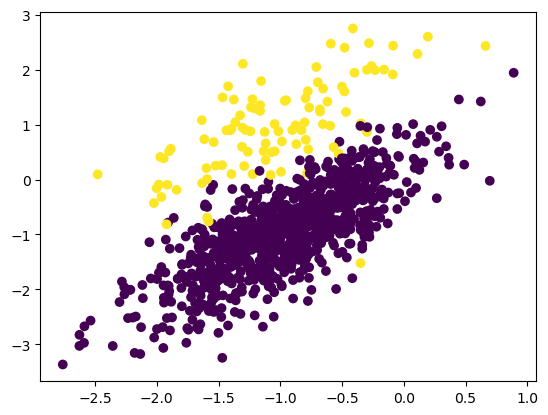

In [6]:
plt.scatter(final_df['f1'],final_df['f2'], c = final_df['target'])

In [7]:
!pip install imblearn

In [8]:
from imblearn.over_sampling import SMOTE

In [12]:
# Now we transform the dataset
## fit_resample(): here the arg1 is the independent feature, 
oversample = SMOTE()
X,y = oversample.fit_resample(final_df[['f1','f2']], final_df['target'])

In [13]:
X.shape

(1800, 2)

In [14]:
y.shape

(1800,)

In [17]:
len(y[y==0])

900

In [18]:
len(y[y==1])

900

In [22]:
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
oversample_df = pd.concat([df1, df2], axis = 1)

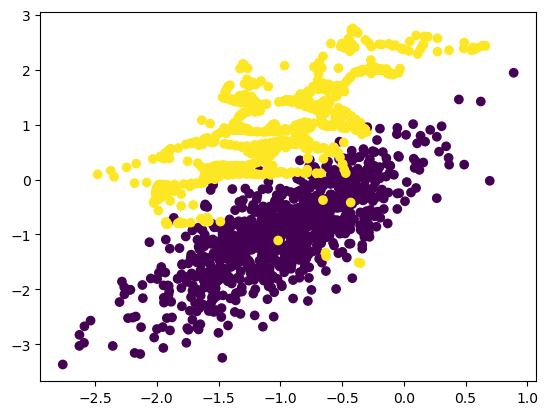

In [23]:
plt.scatter(oversample_df['f1'], oversample_df['f2'], c = oversample_df['target'])